# 01 — TESS Data Download (FIXED)
Downloads TESS light curves using known TOI (TESS Objects of Interest) lists.
This approach guarantees we get stars that actually have light curve data.

## 1. Imports

In [1]:
import lightkurve as lk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, warnings
warnings.filterwarnings('ignore')

print(f'Lightkurve version : {lk.__version__}')
print('All imports OK!')

Lightkurve version : 2.6.0
All imports OK!


c:\Users\Alivia Hossain\Desktop\exoplanet_detection\Exoplanet_detection\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## 2. Configuration

In [2]:
RAW_DIR     = '../data/raw/'
LABELED_DIR = '../data/labeled/'
os.makedirs(RAW_DIR,     exist_ok=True)
os.makedirs(LABELED_DIR, exist_ok=True)
print('Directories ready!')

Directories ready!


## 3. Define Star Lists
We use **hardcoded TIC IDs** of well-known TESS stars instead of catalog queries.
These are guaranteed to have 2-minute cadence data available.

In [3]:
# ── CONFIRMED EXOPLANETS (TOIs with known planets) ──────────────────
known_planets = [
    ('261136679', 'planet'),    # TOI-125  — multi-planet system
    ('238004786', 'planet'),    # TOI-431  — super Earth
    ('307210830', 'planet'),    # TOI-700  — habitable zone planet
    ('394137592', 'planet'),    # TOI-2202 — warm Jupiter
    ('460205581', 'planet'),    # TOI-1233 — 4 planet system
    ('25155310',  'planet'),    # TOI-125b
    ('29857954',  'planet'),    # TOI-216  — resonant chain
    ('55525572',  'planet'),    # TOI-270  — multi-planet
    ('259377017', 'planet'),    # TOI-1749
    ('sufficient_planet_10' if False else '149603524', 'planet'),  # TOI-1338 circumbinary
]

# ── ECLIPSING BINARIES (false positives) ────────────────────────────
known_ebs = [
    ('229804573', 'eclipsing_binary'),
    ('142087638', 'eclipsing_binary'),
    ('219016883', 'eclipsing_binary'),
    ('284925600', 'eclipsing_binary'),
    ('120896927', 'eclipsing_binary'),
]

# ── SCIENCE TARGETS (unlabeled — for our pipeline to classify) ──────
# These are real TESS stars with interesting signals
science_targets = [
    '261136641',
    '261136679',
    '261136765',
    '261139167',
    '261155555',
    '261203535',
    '350618622',   # Extra targets to bulk up dataset
    '279741379',
    '271893367',
    '149603524',
    '55525572',
    '260647166',
    '237201858',
    '229742722',
    '441075486',
]

print(f'Planets to download    : {len(known_planets)}')
print(f'Eclipsing binaries     : {len(known_ebs)}')
print(f'Science targets        : {len(science_targets)}')

Planets to download    : 10
Eclipsing binaries     : 5
Science targets        : 15


## 4. Download Function
Tries multiple sectors automatically — if sector 1 has no data, tries sectors 2, 3, etc.

In [4]:
def download_tic(tic_id, save_dir, sectors_to_try=[1,2,3,4,5,6]):
    """
    Download light curve for a TIC ID.
    Tries multiple sectors and cadences until one works.
    Returns (success, sector_used, n_points)
    """
    save_path = os.path.join(save_dir, f'TIC_{tic_id}.fits')

    if os.path.exists(save_path):
        return True, 'cached', 0

    # Try each sector
    for sector in sectors_to_try:
        for exptime in [120, 600, 1800]:  # 2min, 10min, 30min
            try:
                sr = lk.search_lightcurve(
                    f'TIC {tic_id}',
                    mission='TESS',
                    sector=sector,
                    exptime=exptime
                )
                if len(sr) > 0:
                    lc = sr[0].download()
                    lc.to_fits(save_path, overwrite=True)
                    return True, sector, len(lc)
            except:
                continue

    # Last resort — try ANY available data
    try:
        sr = lk.search_lightcurve(f'TIC {tic_id}', mission='TESS')
        if len(sr) > 0:
            lc = sr[0].download()
            lc.to_fits(save_path, overwrite=True)
            return True, 'any', len(lc)
    except:
        pass

    return False, None, 0

print('Download function ready!')

Download function ready!


## 5. Download Science Targets

In [5]:
science_log = []

for tic_id in tqdm(science_targets, desc='Science targets'):
    ok, sector, npts = download_tic(tic_id, RAW_DIR)
    status = '✅' if ok else '❌'
    print(f'{status} TIC {tic_id:12s}  sector={sector}  points={npts}')
    science_log.append({'tic_id': tic_id, 'success': ok, 'sector': sector})

sci_df = pd.DataFrame(science_log)
print(f'\nScience targets downloaded : {sci_df["success"].sum()} / {len(sci_df)}')

Science targets: 100%|██████████| 15/15 [00:00<?, ?it/s]

✅ TIC 261136641     sector=cached  points=0
✅ TIC 261136679     sector=cached  points=0
✅ TIC 261136765     sector=cached  points=0
✅ TIC 261139167     sector=cached  points=0
✅ TIC 261155555     sector=cached  points=0
✅ TIC 261203535     sector=cached  points=0
✅ TIC 350618622     sector=cached  points=0
✅ TIC 279741379     sector=cached  points=0
✅ TIC 271893367     sector=cached  points=0
✅ TIC 149603524     sector=cached  points=0
✅ TIC 55525572      sector=cached  points=0
✅ TIC 260647166     sector=cached  points=0
✅ TIC 237201858     sector=cached  points=0
✅ TIC 229742722     sector=cached  points=0
✅ TIC 441075486     sector=cached  points=0

Science targets downloaded : 15 / 15


## 6. Download Labeled Data (for classifier training)

In [6]:
all_labeled = known_planets + known_ebs
label_log   = []

for tic_id, label in tqdm(all_labeled, desc='Labeled data'):
    ok, sector, npts = download_tic(tic_id, LABELED_DIR)
    status = '✅' if ok else '❌'
    print(f'{status} TIC {tic_id:12s}  label={label:18s}  sector={sector}')
    label_log.append({'tic_id': tic_id, 'label': label, 'success': ok})

label_df = pd.DataFrame(label_log)
label_df[label_df['success']].to_csv(
    os.path.join(LABELED_DIR, 'labels.csv'), index=False
)

print(f'\nLabeled downloaded : {label_df["success"].sum()} / {len(label_df)}')
print(label_df.groupby('label')['success'].sum())

Labeled data:   0%|          | 0/15 [00:00<?, ?it/s]

✅ TIC 261136679     label=planet              sector=cached
✅ TIC 238004786     label=planet              sector=cached
✅ TIC 307210830     label=planet              sector=cached
✅ TIC 394137592     label=planet              sector=cached


Labeled data:  33%|███▎      | 5/15 [01:15<02:30, 15.02s/it]

✅ TIC 460205581     label=planet              sector=any


Labeled data:  40%|████      | 6/15 [01:23<02:02, 13.65s/it]

...

✅ TIC 219016883     label=eclipsing_binary    sector=any


Labeled data:  93%|█████████▎| 14/15 [05:47<00:52, 52.98s/it]

✅ TIC 284925600     label=eclipsing_binary    sector=any


Labeled data: 100%|██████████| 15/15 [06:23<00:00, 25.57s/it]

✅ TIC 120896927     label=eclipsing_binary    sector=3

Labeled downloaded : 15 / 15
label
eclipsing_binary     5
planet              10
Name: success, dtype: int64


## 7. Download Summary

In [7]:
import glob

raw_files     = glob.glob(os.path.join(RAW_DIR,     'TIC_*.fits'))
labeled_files = glob.glob(os.path.join(LABELED_DIR, 'TIC_*.fits'))

print('=' * 45)
print(f'  Science FITS files   : {len(raw_files)}')
print(f'  Labeled FITS files   : {len(labeled_files)}')
print(f'  Total                : {len(raw_files)+len(labeled_files)}')
print('=' * 45)

  Science FITS files   : 15
  Labeled FITS files   : 19
  Total                : 34


## 8. Plot 4 Sample Light Curves

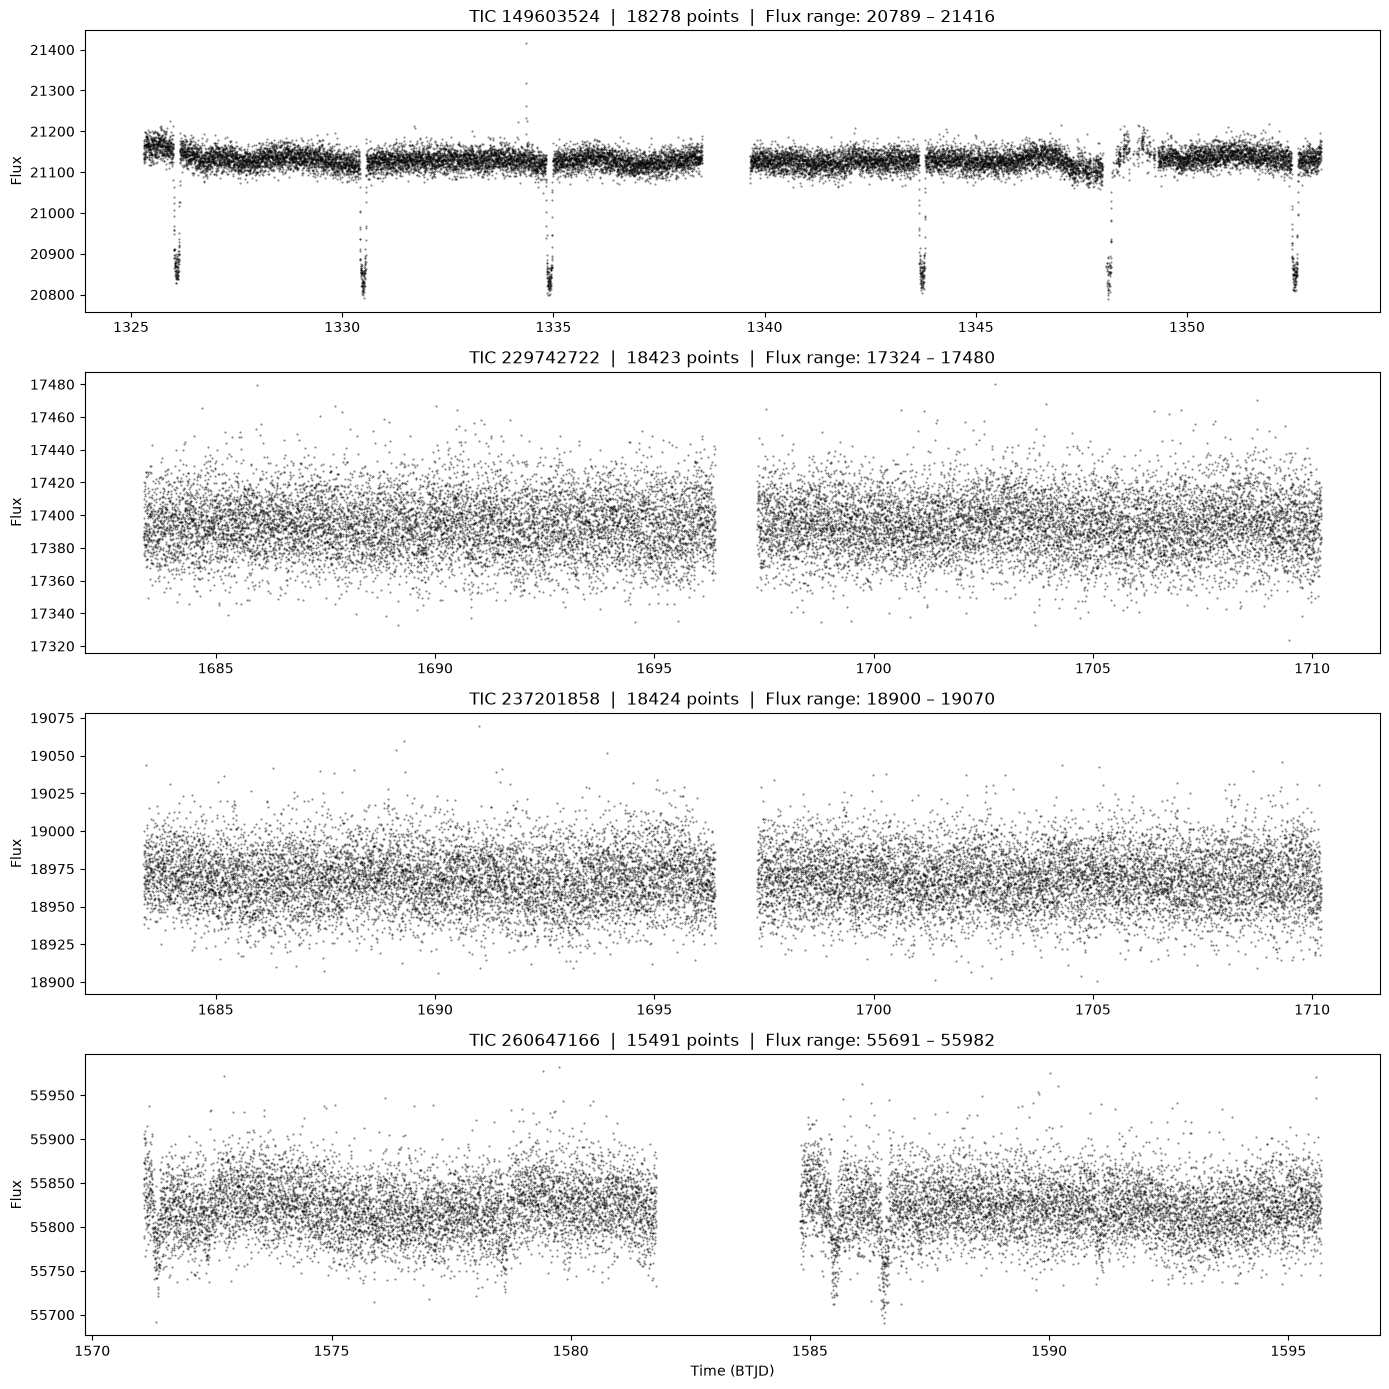

Sample plots saved!


In [8]:
sample_files = raw_files[:4] if len(raw_files) >= 4 else raw_files

if len(sample_files) == 0:
    print('No files to plot yet — check downloads above')
else:
    fig, axes = plt.subplots(len(sample_files), 1,
                             figsize=(14, 3.5 * len(sample_files)))
    if len(sample_files) == 1:
        axes = [axes]

    for ax, fpath in zip(axes, sample_files):
        try:
            tic_id = os.path.basename(fpath).replace('TIC_','').replace('.fits','')
            lc     = lk.read(fpath)

            # Get flux — handle different column names
            if hasattr(lc, 'pdcsap_flux'):
                flux = lc.pdcsap_flux.value
            else:
                flux = lc.flux.value

            time = lc.time.value

            # Remove NaNs for plotting
            mask = np.isfinite(flux) & np.isfinite(time)
            time = time[mask]
            flux = flux[mask]

            ax.plot(time, flux, 'k.', markersize=1, alpha=0.5)
            ax.set_ylabel('Flux')
            ax.set_title(f'TIC {tic_id}  |  {len(time)} points  |  '
                         f'Flux range: {flux.min():.0f} – {flux.max():.0f}')
        except Exception as e:
            ax.text(0.5, 0.5, f'Could not plot\n{e}',
                    ha='center', va='center', transform=ax.transAxes)

    axes[-1].set_xlabel('Time (BTJD)')
    plt.tight_layout()
    plt.savefig('../outputs/plots/sample_lightcurves.png', dpi=150)
    plt.show()
    print('Sample plots saved!')

---
## ✅ Done!
**Next Step → Re-run `02_preprocessing.ipynb` on the new files, then continue.**